# 02 — Retrieval & Recommendation Modeling

**Amazon Review Intelligence — Model Analysis**

This notebook analyzes the search and recommendation models: BM25 retrieval quality, embedding space structure, and recommender coverage. Run `make index` first.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import duckdb
import json
import joblib
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DB = Path('../data/amazon_reviews.duckdb')
BM25_PATH = Path('../data/bm25_index.joblib')
conn = duckdb.connect(str(DB), read_only=True)
print('Connected to DuckDB')

Connected to DuckDB


## 1. BM25 Index Analysis

BM25 corpus: 83,119 documents
BM25 average document length (tokens): 4.3


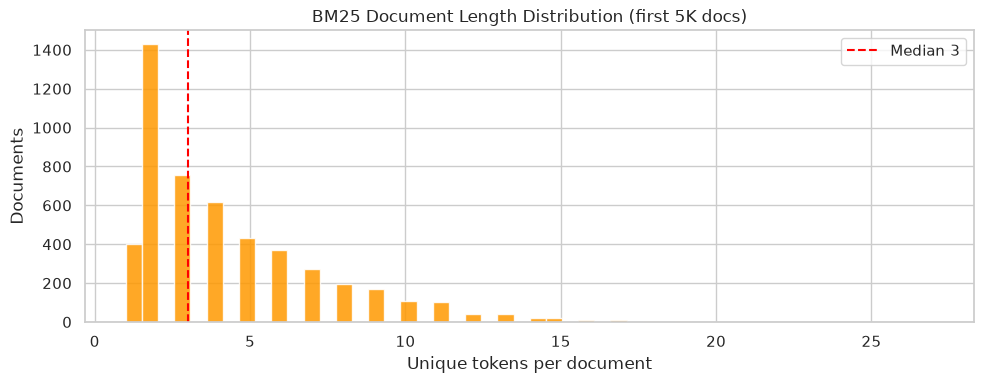

In [2]:
bm25_bundle = joblib.load(BM25_PATH)
bm25 = bm25_bundle['index']
doc_ids = bm25_bundle['doc_ids']
corpus = bm25_bundle['corpus_texts']  # key name in this project

print(f'BM25 corpus: {len(doc_ids):,} documents')
print(f'BM25 average document length (tokens): {bm25.avgdl:.1f}')

# Document length distribution
doc_lens = [len(bm25.doc_freqs[i]) for i in range(min(5000, len(bm25.doc_freqs)))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(doc_lens, bins=50, color='#FF9900', alpha=0.85)
ax.axvline(np.median(doc_lens), color='red', linestyle='--', label=f'Median {np.median(doc_lens):.0f}')
ax.set_title('BM25 Document Length Distribution (first 5K docs)')
ax.set_xlabel('Unique tokens per document')
ax.set_ylabel('Documents')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/screenshots/modeling_bm25_doc_len.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. BM25 Query Demo — Score Distributions

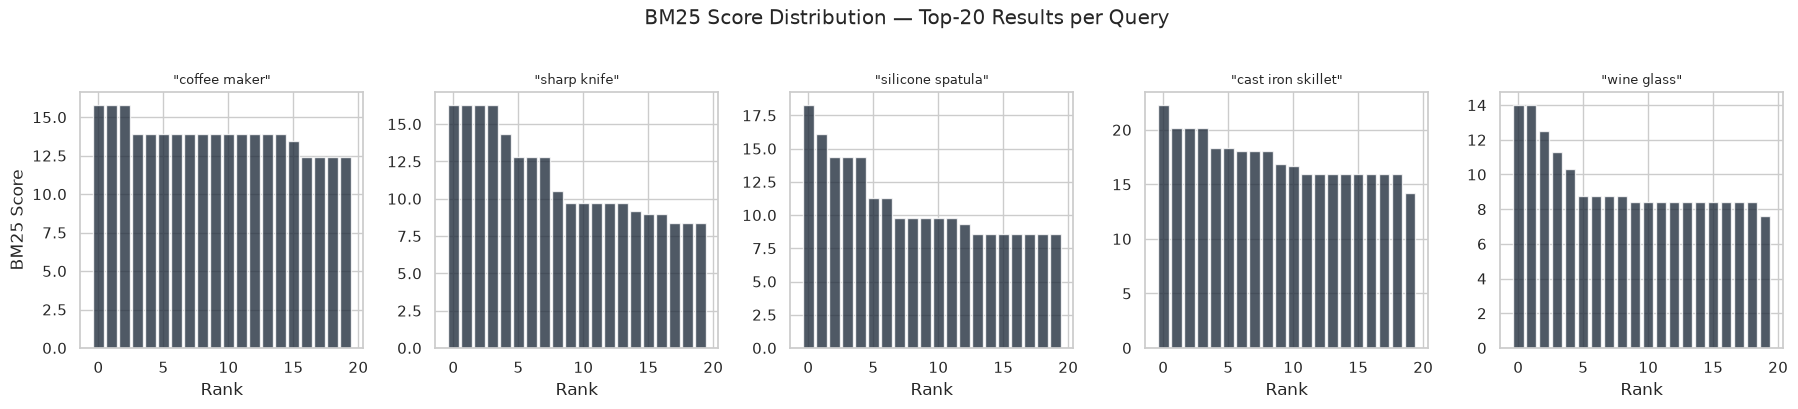

Steep drop-off = high precision; gradual = broad match.


In [3]:
demo_queries = ['coffee maker', 'sharp knife', 'silicone spatula', 'cast iron skillet', 'wine glass']

fig, axes = plt.subplots(1, len(demo_queries), figsize=(18, 4), sharey=False)

for ax, q in zip(axes, demo_queries):
    tokens = q.lower().split()
    scores = bm25.get_scores(tokens)
    top_scores = sorted(scores, reverse=True)[:20]
    ax.bar(range(len(top_scores)), top_scores, color='#232F3E', alpha=0.8)
    ax.set_title(f'"{q}"', fontsize=9)
    ax.set_xlabel('Rank')
    ax.set_ylabel('BM25 Score' if ax is axes[0] else '')

plt.suptitle('BM25 Score Distribution — Top-20 Results per Query', y=1.02)
plt.tight_layout()
plt.savefig('../docs/screenshots/modeling_bm25_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('Steep drop-off = high precision; gradual = broad match.')

## 3. Embedding Space Analysis

Loaded 2000 embeddings, shape: (2000, 384)


PCA explained variance: 9.7%


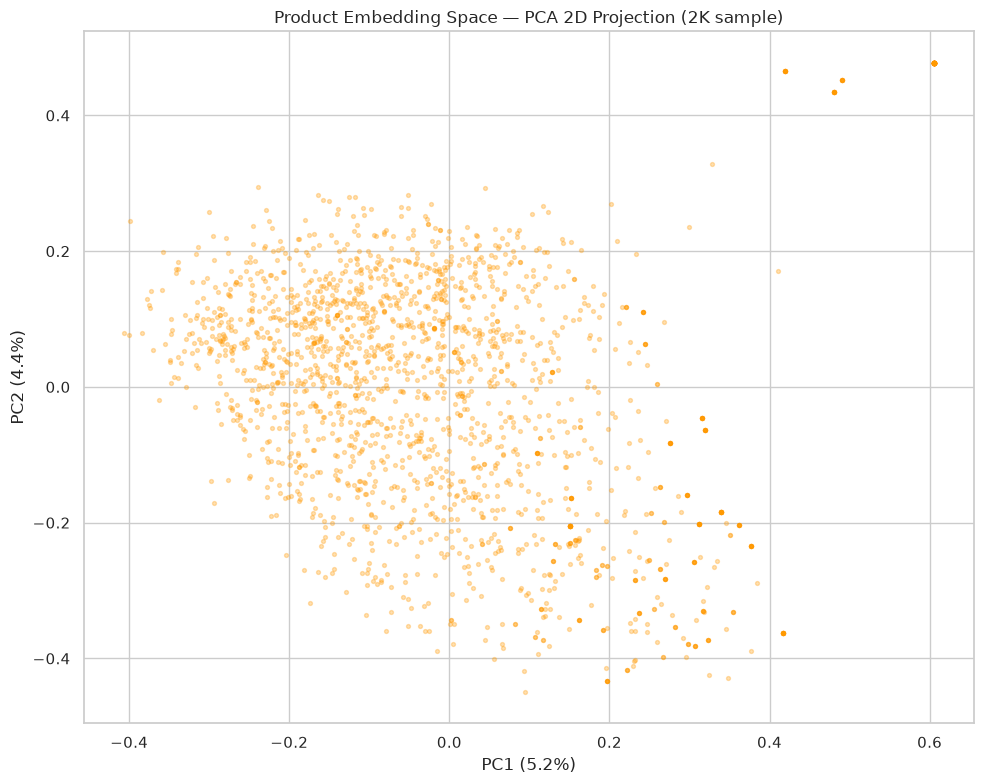

In [4]:
# Sample 2000 embeddings for visualization
emb_rows = conn.execute(
    'SELECT e.asin, e.embedding FROM product_embeddings e ORDER BY random() LIMIT 2000'
).fetchall()

asins = [r[0] for r in emb_rows]
embeddings = np.array([r[1] for r in emb_rows], dtype='float32')
print(f'Loaded {len(embeddings)} embeddings, shape: {embeddings.shape}')

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(embeddings)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.3, s=8, c='#FF9900')
ax.set_title('Product Embedding Space — PCA 2D Projection (2K sample)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig('../docs/screenshots/modeling_embedding_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Intra-Catalog Cosine Similarity Distribution

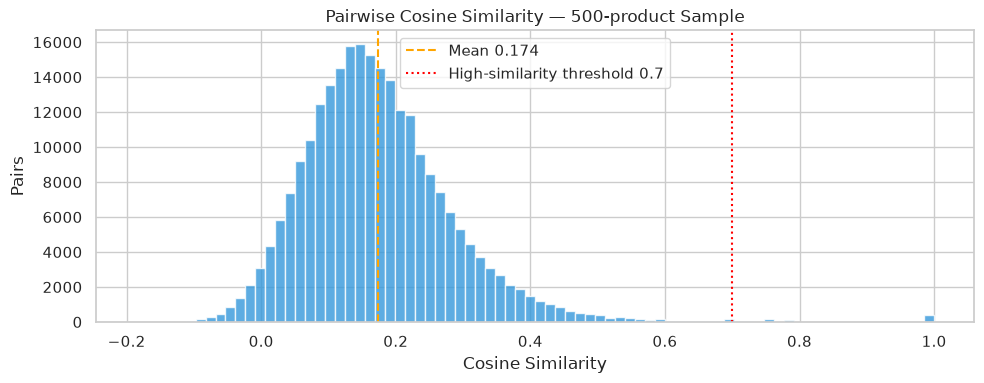

Pairs with cosine > 0.7 (semantically near-duplicate): 0.3%
All products are Home & Kitchen — high baseline similarity is expected.


In [5]:
# Sample 500 embeddings and compute pairwise cosine similarity
sample_emb = embeddings[:500]
sim_matrix = cosine_similarity(sample_emb)
# Exclude diagonal (self-similarity = 1.0)
mask = np.ones(sim_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
sims = sim_matrix[mask]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sims, bins=80, color='#3498db', alpha=0.8)
ax.axvline(sims.mean(), color='orange', linestyle='--', label=f'Mean {sims.mean():.3f}')
ax.axvline(0.7, color='red', linestyle=':', label='High-similarity threshold 0.7')
ax.set_title('Pairwise Cosine Similarity — 500-product Sample')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Pairs')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/screenshots/modeling_cosine_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pairs with cosine > 0.7 (semantically near-duplicate): {(sims > 0.7).mean()*100:.1f}%')
print(f'All products are Home & Kitchen — high baseline similarity is expected.')

## 5. Search Evaluation Results

In [6]:
with open('../data/evaluation_results.json') as f:
    results = json.load(f)

search_results = results.get('search_results', results)  # handle either key
print(json.dumps(search_results, indent=2))

{
  "search_bm25": {
    "recall": {
      "5": 0.0,
      "10": 0.0001,
      "20": 0.0002
    },
    "mrr": {
      "5": 0.5,
      "10": 0.5,
      "20": 0.5
    },
    "ndcg": {
      "5": 0.6608,
      "10": 0.7799,
      "20": 0.858
    }
  },
  "search_vector": {
    "recall": {
      "5": 0.0,
      "10": 0.0001,
      "20": 0.0002
    },
    "mrr": {
      "5": 0.575,
      "10": 0.575,
      "20": 0.575
    },
    "ndcg": {
      "5": 0.6796,
      "10": 0.7921,
      "20": 0.8658
    }
  },
  "search_hybrid": {
    "recall": {
      "5": 0.0,
      "10": 0.0001,
      "20": 0.0002
    },
    "mrr": {
      "5": 0.575,
      "10": 0.575,
      "20": 0.575
    },
    "ndcg": {
      "5": 0.6796,
      "10": 0.7921,
      "20": 0.8658
    }
  },
  "recommendation_cold_start": {
    "precision": {
      "5": 0.0,
      "10": 0.0,
      "20": 0.0
    },
    "recall": {
      "5": 0.0,
      "10": 0.0,
      "20": 0.0
    },
    "map": {
      "5": 0.0,
      "10": 0.0,
      "20"

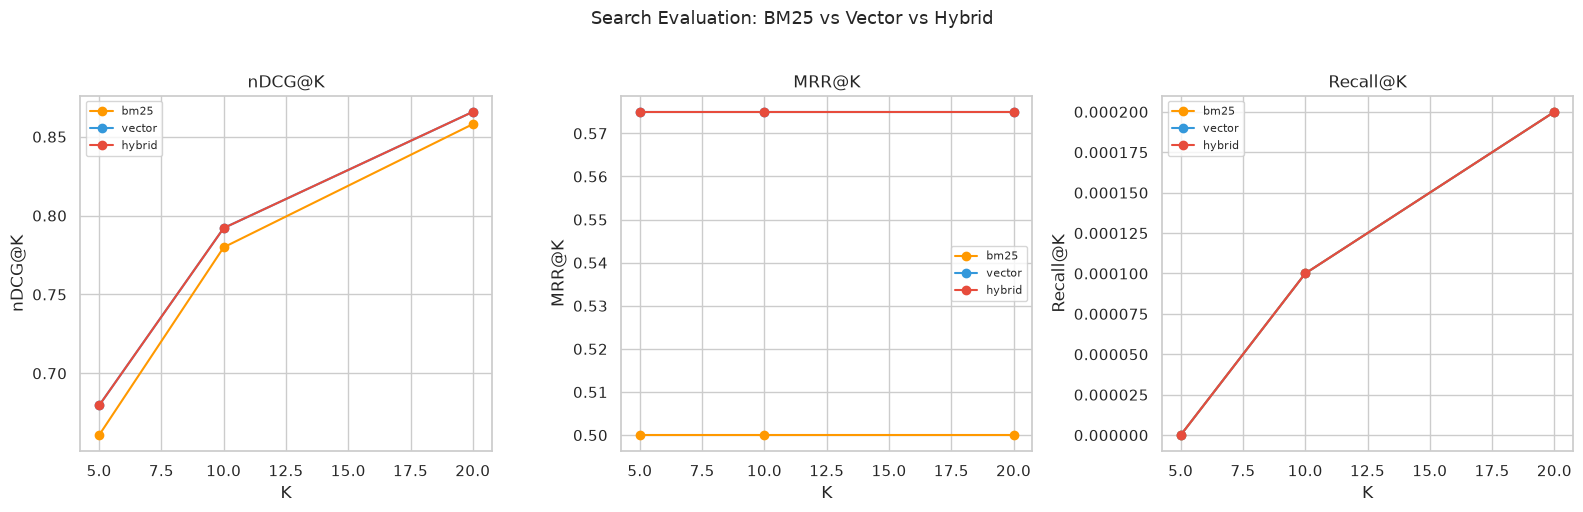

Note: Recall ≈ 0 because all 83K products share one category (denominator = 83K).
MRR and nDCG are the informative metrics here.


In [7]:
# Structure: results[method][metric][k_str] = value
# e.g. results['search_bm25']['ndcg']['10'] = 0.7799
search_methods = [k for k in results.keys() if k.startswith('search_')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_keys = ['ndcg', 'mrr', 'recall']
metric_labels = ['nDCG@K', 'MRR@K', 'Recall@K']
palette = ['#FF9900', '#3498db', '#e74c3c']

for ax, mkey, mlabel in zip(axes, metric_keys, metric_labels):
    for method, color in zip(search_methods, palette):
        sub = results[method][mkey]  # {'5': v, '10': v, '20': v}
        ks = sorted(sub.keys(), key=int)
        vals = [sub[k] for k in ks]
        ax.plot([int(k) for k in ks], vals, marker='o',
                label=method.replace('search_', ''), color=color)
    ax.set_title(mlabel)
    ax.set_xlabel('K')
    ax.set_ylabel(mlabel)
    ax.legend(fontsize=8)

plt.suptitle('Search Evaluation: BM25 vs Vector vs Hybrid', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../docs/screenshots/modeling_search_eval.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: Recall ≈ 0 because all 83K products share one category (denominator = 83K).')
print('MRR and nDCG are the informative metrics here.')

## 6. Recommender Coverage Analysis

In [8]:
reco_results = results.get('reco_results', {})

# If available, plot recommendation metrics
if reco_results:
    print('Recommendation metrics:')
    print(json.dumps(reco_results, indent=2))
else:
    print('Reco results format varies — loading from full results JSON.')
    print(json.dumps({k: v for k, v in results.items() if 'reco' in k.lower() or 'recommend' in k.lower()}, indent=2))

Reco results format varies — loading from full results JSON.
{
  "recommendation_cold_start": {
    "precision": {
      "5": 0.0,
      "10": 0.0,
      "20": 0.0
    },
    "recall": {
      "5": 0.0,
      "10": 0.0,
      "20": 0.0
    },
    "map": {
      "5": 0.0,
      "10": 0.0,
      "20": 0.0
    },
    "coverage": {
      "5": 0.022822699984359773,
      "10": 0.022822699984359773,
      "20": 0.022822699984359773
    }
  }
}


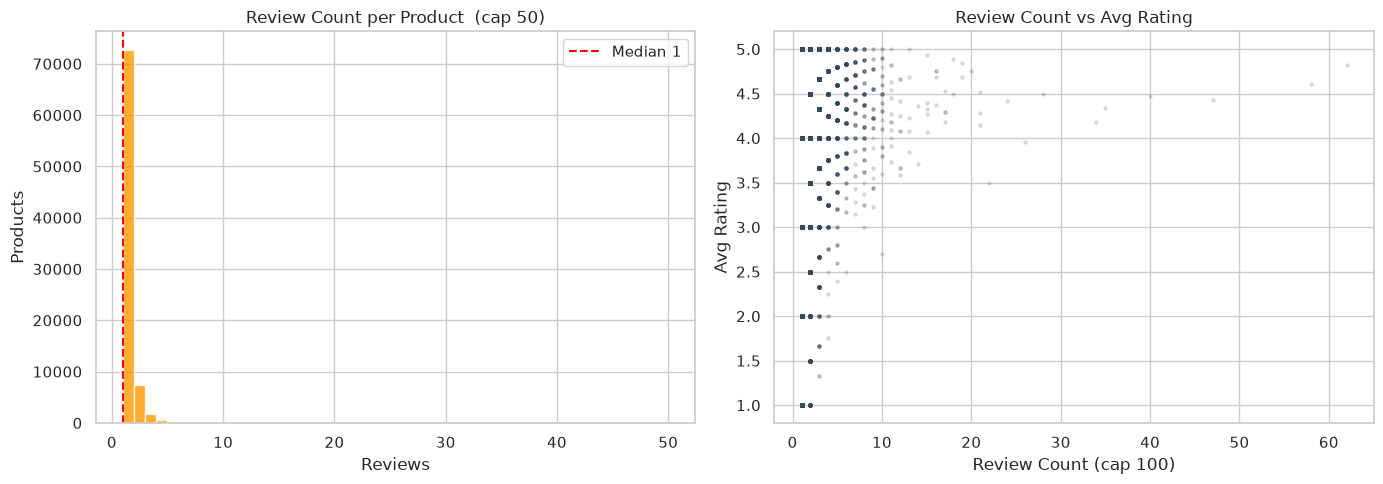

Top-50 products by popularity score cover 0.06% of catalog
Max review count: 62
% products with 1 review: 87.5%

Modeling notebook complete.


In [9]:
# Top-N product frequency from review data (proxy for popularity recommender)
reviews = conn.execute('SELECT asin, rating FROM reviews').df()
products = conn.execute('SELECT asin, rating_number, avg_rating FROM products').df()

# Popularity score
products['popularity_score'] = products['avg_rating'] * np.log1p(products['rating_number'])
top50 = products.nlargest(50, 'popularity_score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(products['rating_number'].clip(0, 50), bins=50, color='#FF9900', alpha=0.8)
axes[0].set_title('Review Count per Product  (cap 50)')
axes[0].set_xlabel('Reviews')
axes[0].set_ylabel('Products')
axes[0].axvline(products['rating_number'].median(), color='red', linestyle='--',
                label=f'Median {products["rating_number"].median():.0f}')
axes[0].legend()

axes[1].scatter(products['rating_number'].clip(0, 100), products['avg_rating'],
               alpha=0.15, s=5, c='#37475A')
axes[1].set_title('Review Count vs Avg Rating')
axes[1].set_xlabel('Review Count (cap 100)')
axes[1].set_ylabel('Avg Rating')

plt.tight_layout()
plt.savefig('../docs/screenshots/modeling_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Top-50 products by popularity score cover {len(top50)/len(products)*100:.2f}% of catalog')
print(f'Max review count: {products["rating_number"].max()}')
print(f'% products with 1 review: {(products["rating_number"]==1).mean()*100:.1f}%')

conn.close()
print('\nModeling notebook complete.')